In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader
import timm
import matplotlib.pyplot as plt
import numpy as np
import cv2
from einops import rearrange
from sklearn.metrics import classification_report
import random

torch.manual_seed(42)
random.seed(42)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


## 1. Loading the Oxford-IIIT Pets Dataset

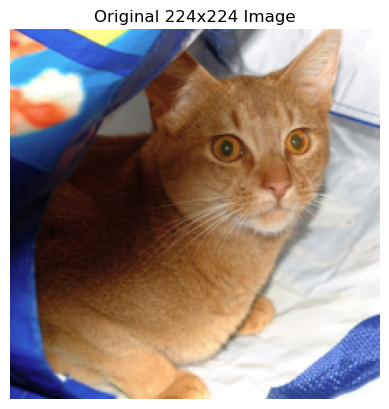

In [2]:
transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
])

dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='trainval', transform=transform, download=True)

img_tensor, label = dataset[0] # Picking an image of a pet

def show_image(tensor, title=None):
    img = tensor.permute(1, 2, 0).numpy()
    plt.imshow(img)
    if title: plt.title(title)
    plt.axis('off')
    plt.show()

show_image(img_tensor, title="Original 224x224 Image")

## 2. The Patches

Original shape: torch.Size([3, 224, 224])
Patches shape: torch.Size([196, 3, 16, 16]) -> (Number of Patches, Channels, Patch_H, Patch_W)


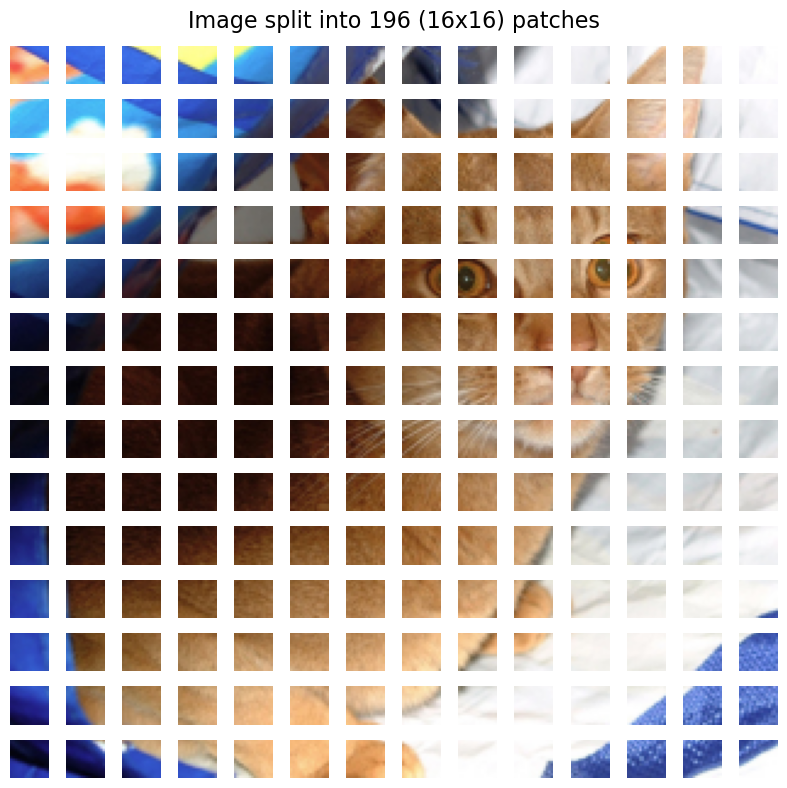

In [3]:
patch_size = 16

# c: channels, h & w: height & width, p1 & p2: patch dimensions
patches = rearrange(img_tensor, 'c (h p1) (w p2) -> (h w) c p1 p2', p1=patch_size, p2=patch_size)

print(f"Original shape: {img_tensor.shape}")
print(f"Patches shape: {patches.shape} -> (Number of Patches, Channels, Patch_H, Patch_W)")

fig, axes = plt.subplots(14, 14, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    patch_img = patches[i].permute(1, 2, 0).numpy()
    ax.imshow(patch_img)
    ax.axis('off')
plt.suptitle("Image split into 196 (16x16) patches", fontsize=16)
plt.tight_layout()
plt.savefig('visuals/patches.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Pre-trained ViT & Extracting Attention
Training a ViT from scratch requires massive datasets. For this project, I am using a pre-trained `vit_base_patch16_224` from the `timm` library. 

To see what the model is focusing on, I will use a PyTorch **forward hook** to intercept the attention weights from the final transformer block before they are passed to the classification head.

In [4]:
# Pre-trained model
model = timm.create_model('vit_base_patch16_224', pretrained=True)
for block in model.blocks:
    if hasattr(block.attn, 'fused_attn'):
        block.attn.fused_attn = False
model.eval()
model.to(device)

attention_weights = {}

def get_attention(name):
    def hook(module, input, output):
        # The output of the attention module in timm's ViT contains the attention scores
        attention_weights[name] = output
    return hook

# Register the hook to the attention layer of the last transformer block (block 11 in a 12-block base model)
model.blocks[-1].attn.attn_drop.register_forward_hook(get_attention('last_layer_attn'))

# ImageNet normalization values
normalize = T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
input_tensor = normalize(img_tensor).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)


## 4. Attention Map
The attention matrix tells us how much every token attends to every other token. We are specifically interested in the `[CLS]` token (index 0). By looking at the `[CLS]` token's attention weights towards all the other 196 image patch tokens, we can see exactly which parts of the image drove the final classification decision.

Attention shape: torch.Size([1, 12, 197, 197]) -> (Batch, Heads, Seq_Len, Seq_Len)


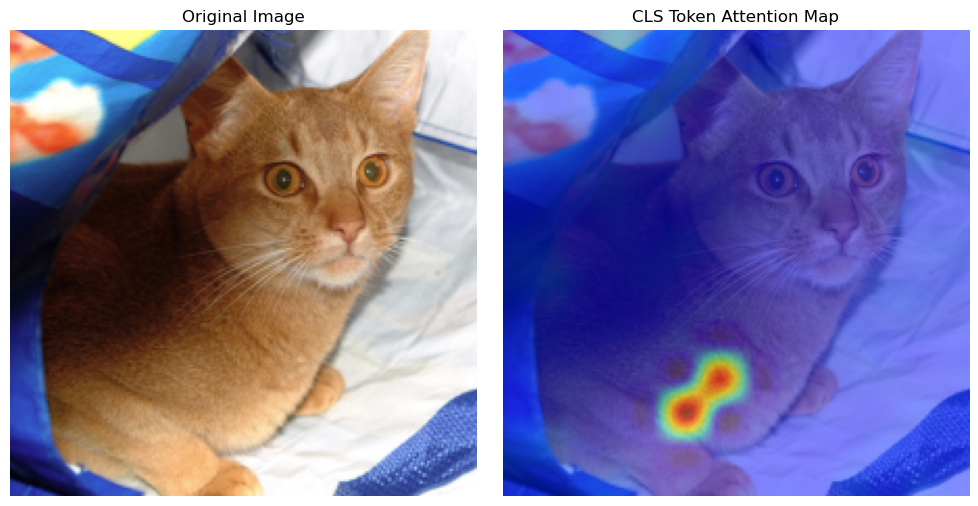

In [5]:
attn = attention_weights['last_layer_attn']
print(f"Attention shape: {attn.shape} -> (Batch, Heads, Seq_Len, Seq_Len)")

attn_mean = torch.mean(attn, dim=1).squeeze(0) # Shape: (197, 197)

# CLS token is at index 0. Image patches start at index 1. Display the attention from CLS token to all patches (excluding itself).
cls_attention = attn_mean[0, 1:] 

# Reshape the 196 flat sequence back into a 14x14 grid
cls_attention = cls_attention.reshape(14, 14).cpu().numpy()

# Resize the 14x14 attention map back to the original 224x224 image size using cubic interpolation
attn_resized = cv2.resize(cls_attention, (224, 224), interpolation=cv2.INTER_CUBIC)

attn_resized = (attn_resized - attn_resized.min()) / (attn_resized.max() - attn_resized.min())

# Create a heatmap overlay
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

original_img = img_tensor.permute(1, 2, 0).numpy()
ax[0].imshow(original_img)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(original_img)
ax[1].imshow(attn_resized, cmap='jet', alpha=0.5)
ax[1].set_title('CLS Token Attention Map')
ax[1].axis('off')

plt.tight_layout()
plt.savefig('visuals/attention_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Transfer Learning: Fine-Tuning the Classification Head

Up to this point, we have been using the ViT as a pre-trained feature extractor. By default, `vit_base_patch16_224` projects its final `[CLS]` token embedding—a dense vector in a $768$-dimensional latent space—into $1000$ distinct ImageNet classes. 

Mathematically, this final classification head is just a linear projection matrix $W_{ImageNet} \in \mathbb{R}^{768 \times 1000}$. 

To adapt this model for our specific task (classifying the 37 breeds in the Oxford-IIIT Pets dataset), we will apply **Transfer Learning**. 

In [6]:
# 1. Freeze the base model parameters
for param in model.parameters():
    param.requires_grad = False

# 2. Replace the classification head and Oxford-IIIT Pet dataset has 37 distinct categories
num_classes = 37
in_features = model.head.in_features 

# Assign a freshly initialized Linear layer. 
model.head = nn.Linear(in_features, num_classes)
model.to(device)

print(f"Replaced classification head: {in_features} -> {num_classes}")

Replaced classification head: 768 -> 37


In [7]:
train_dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='trainval', transform=transform)
test_dataset = torchvision.datasets.OxfordIIITPet(root='./data', split='test', transform=transform)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

Starting training...
Epoch [1/3] - Loss: 0.5964 - Accuracy: 86.09%
Epoch [2/3] - Loss: 0.1248 - Accuracy: 97.12%
Epoch [3/3] - Loss: 0.0731 - Accuracy: 98.26%
Fine-tuning complete!


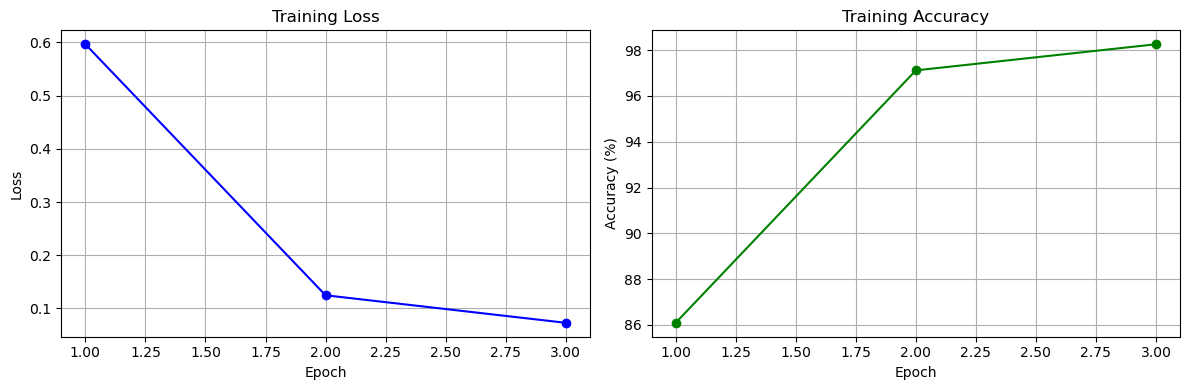

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.head.parameters(), lr=1e-3) # Only optimize the newly initialized head

num_epochs = 3 # Small for testing

train_losses = []
train_accs = []

print("Starting training...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    epoch_loss = running_loss / total
    epoch_acc = 100 * correct / total
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")

print("Fine-tuning complete!")

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, num_epochs + 1), train_losses, 'b-o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss')
ax1.grid(True)

ax2.plot(range(1, num_epochs + 1), train_accs, 'g-o')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training Accuracy')
ax2.grid(True)

plt.tight_layout()
plt.savefig('visuals/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

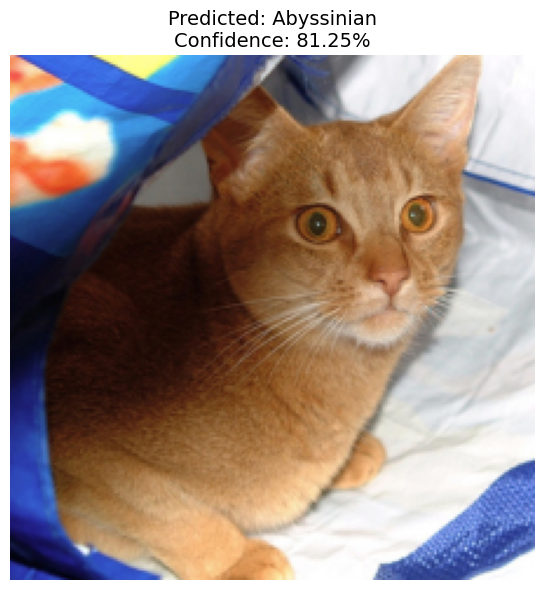

Ground Truth Label Index: 0
Ground Truth Class: Abyssinian
Predicted Class: Abyssinian
Confidence: 81.25%


In [9]:
model.eval()

class_names = train_dataset.classes

input_tensor = normalize(img_tensor).unsqueeze(0).to(device)

with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = torch.nn.functional.softmax(outputs, dim=1)
    confidence, predicted_idx = torch.max(probabilities, 1)

predicted_class = class_names[predicted_idx.item()]
confidence_pct = confidence.item() * 100

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(img_tensor.permute(1, 2, 0).numpy())
ax.set_title(f"Predicted: {predicted_class}\nConfidence: {confidence_pct:.2f}%", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"Ground Truth Label Index: {label}")
print(f"Ground Truth Class: {class_names[label]}")
print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence_pct:.2f}%")

## 6. Evaluation on Test Set
Evaluate fine-tuned model on the test set and visualize its predictions across different pet breeds.

Test Accuracy: 93.59%

Classification Report:
                            precision    recall  f1-score   support

                Abyssinian      0.956     0.888     0.921        98
          American Bulldog      0.836     0.920     0.876       100
 American Pit Bull Terrier      0.897     0.700     0.787       100
              Basset Hound      0.970     0.980     0.975       100
                    Beagle      0.980     0.960     0.970       100
                    Bengal      0.859     0.670     0.753       100
                    Birman      0.825     0.800     0.812       100
                    Bombay      0.861     0.989     0.921        88
                     Boxer      0.911     0.929     0.920        99
         British Shorthair      0.891     0.820     0.854       100
                 Chihuahua      0.960     0.950     0.955       100
              Egyptian Mau      0.703     0.928     0.800        97
    English Cocker Spaniel      1.000     0.990     0.995       100
 

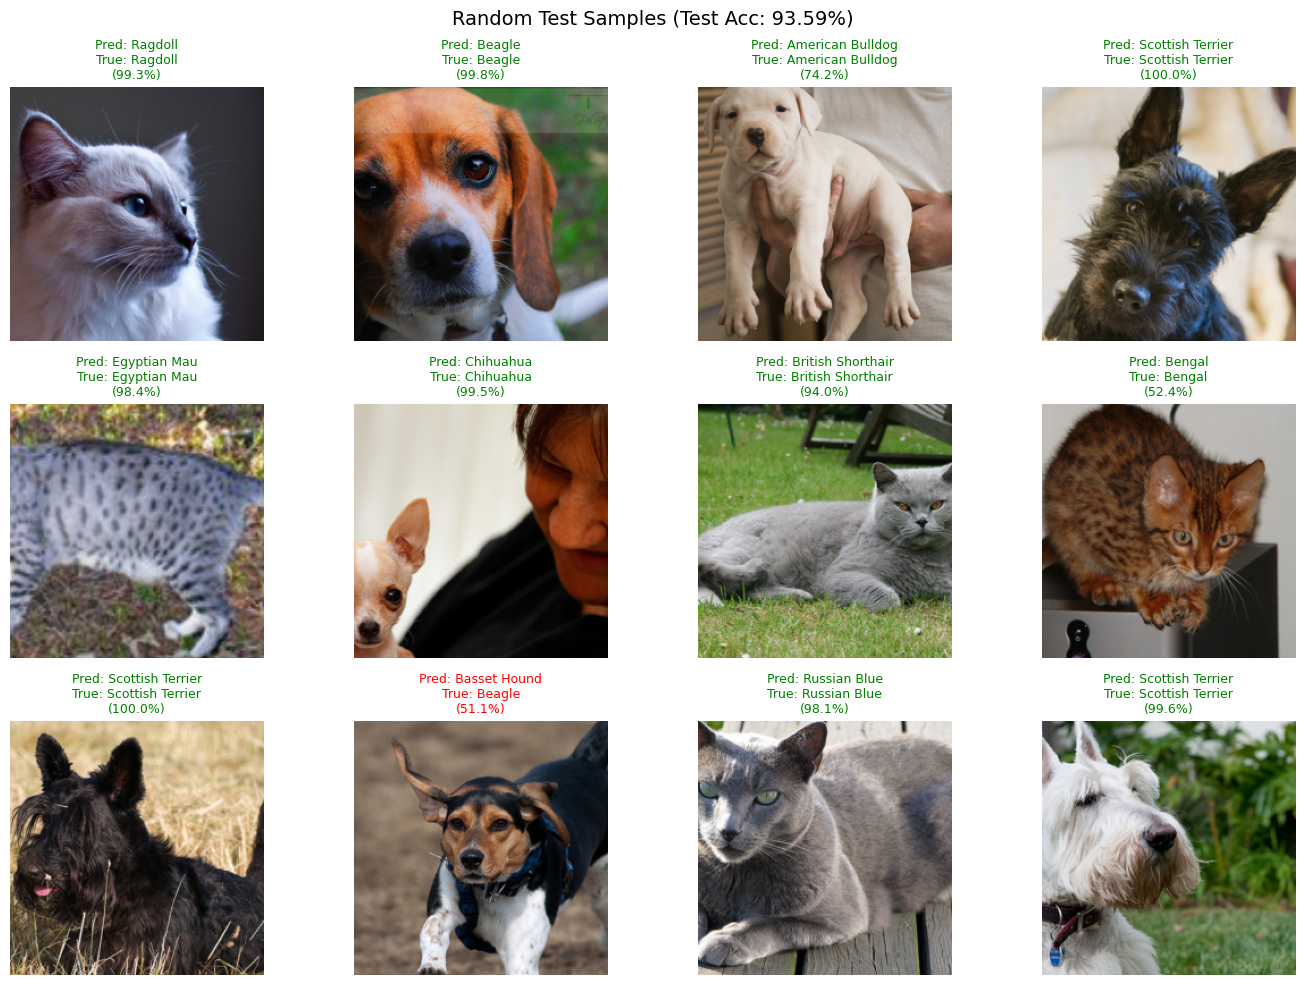

In [10]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = 100 * (all_preds == all_labels).sum() / len(all_labels)
print(f"Test Accuracy: {test_acc:.2f}%\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

sample_indices = random.sample(range(len(test_dataset)), 12)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax, idx in zip(axes.flat, sample_indices):
    img, true_label = test_dataset[idx]
    input_img = normalize(img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(input_img)
        prob = torch.nn.functional.softmax(output, dim=1)
        conf, pred_idx = torch.max(prob, 1)
    
    pred_class = class_names[pred_idx.item()]
    true_class = class_names[true_label]
    confidence = conf.item() * 100
    
    ax.imshow(img.permute(1, 2, 0).numpy())
    color = 'green' if pred_idx.item() == true_label else 'red'
    ax.set_title(f"Pred: {pred_class}\nTrue: {true_class}\n({confidence:.1f}%)", 
                 fontsize=9, color=color)
    ax.axis('off')

plt.suptitle(f"Random Test Samples (Test Acc: {test_acc:.2f}%)", fontsize=14)
plt.tight_layout()
plt.savefig('visuals/test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()